# Day 1.5 — The Agent Loop — You Build It
After one tool result the model may ask for another tool, or answer. That is a **loop**, and
the loop is what makes a program *agentic*. Your code must own two things the model cannot:
**termination** (a step limit) and **safety** (validate every request). This is the day's one
hands-on exercise: write the loop yourself, check it, then compare with the reference.

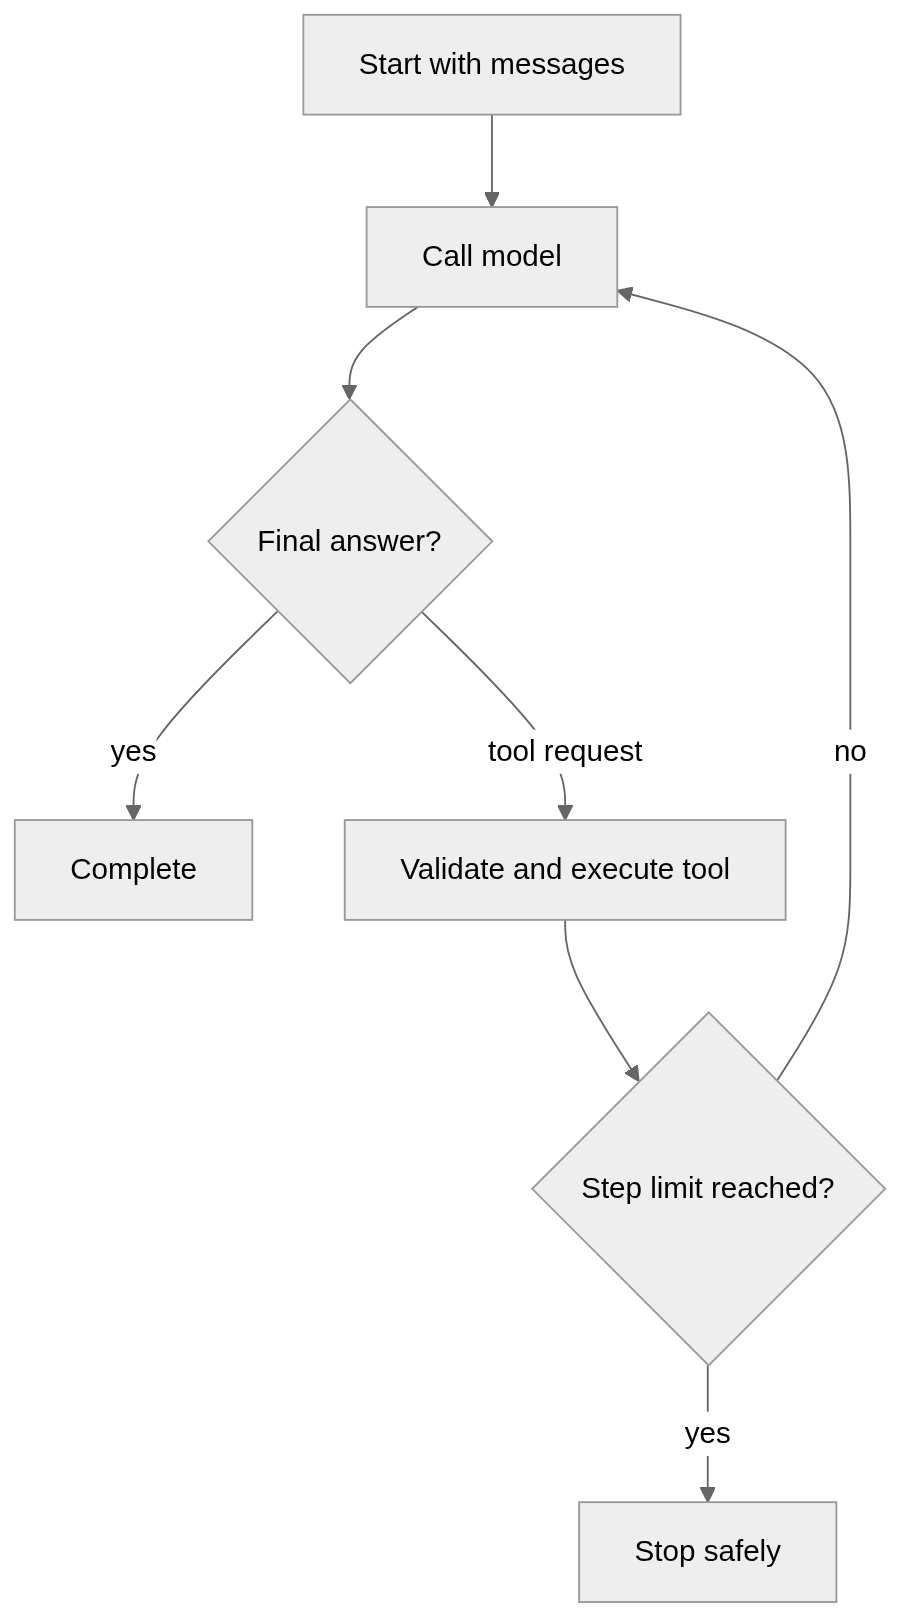

*D04 — call the model; if final answer stop; else validate and execute the tool; stop safely at the step limit*

### Why the program owns termination

"Stop when you are done" in a prompt is not a limit. A confused model can repeat a request
forever, and each turn costs tokens and money. Small errors also compound: if each decision is
95% right, ten independent decisions are all right only about 60% of the time
(`0.95 ** 10 ≈ 0.60`). Bounded loops, validation, and fewer calls are the remedy.

### The contract

```python
run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None)
```
returns a dict with `status` (`"completed"`, `"max_steps"` or `"failed"`), `answer`, `messages`,
`steps`, `tools_used`, `usage`, `error`. Rules: append every tool result; stop on a final answer;
return `"failed"` for an unknown tool or a repeated identical request; return `"max_steps"` when
the limit is reached. Everything you need already exists: `chat`, `assistant_message`, `execute_tool_call`.

In [ ]:
SYSTEM_PROMPT = "You are a careful research assistant. Use tools when they help. Answer only when you have what you need."

def run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None):
    """YOUR TURN. Return {"status", "answer", "messages", "steps", "tools_used", "usage", "error"}."""
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    tool_schemas = [t["schema"] for t in tools.values()]
    # TODO: for step in 1..max_steps:
    # TODO:     reply = model(messages, tools=tool_schemas, response_format=response_format)
    # TODO:     append assistant_message(reply)
    # TODO:     if no tool_calls -> return status "completed" with reply["content"]
    # TODO:     for each call: reject unknown tools and repeated identical requests (status "failed"),
    # TODO:                    otherwise execute_tool_call and append a "tool" message
    # TODO: after the loop -> status "max_steps"
    raise NotImplementedError("write the loop")

print("run_agent stub defined - fill in the TODOs, then run the check below")

### Behavioural check

A scripted fake model stands in for `chat`, so the check is exact and free. It prints a hint
instead of failing while your function is unfinished.

In [ ]:
def make_fake_model(script):
    """A stand-in model that returns the scripted replies in order (same interface as chat)."""
    replies = iter(script)
    def fake(messages, tools=None, response_format=None):
        return next(replies)
    return fake

class AddArgs(BaseModel):
    a: float
    b: float

def run_loop_checks():
    calls = []
    def add(a, b):
        calls.append((a, b)); return str(a + b)
    add_tool = {"add": make_tool("add", "Add two numbers.", add, AddArgs)}

    # Case 1: one tool request, then a final answer.
    script = [_mock_reply(calls=[{"id": "c1", "name": "add", "arguments": {"a": 2, "b": 3}}]),
              _mock_reply("The result is 5.")]
    result = run_agent("Add 2 and 3", add_tool, model=make_fake_model(script))
    assert result["status"] == "completed" and result["answer"] == "The result is 5.", result
    assert calls == [(2, 3)], "the tool must run exactly once with the model's arguments"
    assert any(m["role"] == "tool" for m in result["messages"]), "the tool result must be appended"

    # Case 2: an unknown tool must be rejected before anything runs.
    script = [_mock_reply(calls=[{"id": "c2", "name": "delete_everything", "arguments": {}}])]
    assert run_agent("x", add_tool, model=make_fake_model(script))["status"] == "failed"

    # Case 3: a model that never answers must hit the step limit.
    forever = lambda messages, tools=None, response_format=None: _mock_reply(
        calls=[{"id": f"c{len(messages)}", "name": "add", "arguments": {"a": len(messages), "b": 1}}])
    assert run_agent("x", add_tool, model=forever, max_steps=3)["status"] == "max_steps"
    print("PASS: dispatch, unknown-tool rejection, and the step limit all behave correctly")

try:
    run_loop_checks()
except NotImplementedError:
    print("Not implemented yet. Fill in run_agent above, or read the reference solution below and re-run this cell.")

### Reference solution

Read it line by line even if your check passed, then re-run the check cell. **This version is
the loop used for the rest of the day.**

In [ ]:
# --- Reference solution ------------------------------------------------------------
def run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None):
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    tool_schemas = [t["schema"] for t in tools.values()]
    usage = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    seen_requests, tools_used = set(), []

    def finish(status, answer="", error=None, steps=0):
        return {"status": status, "answer": answer, "messages": messages, "steps": steps,
                "tools_used": tools_used, "usage": usage, "error": error}

    for step in range(1, max_steps + 1):                      # bounded: never loops forever
        reply = model(messages, tools=tool_schemas, response_format=response_format)
        for key in usage:
            usage[key] += reply["usage"].get(key, 0)
        messages.append(assistant_message(reply))             # the model's turn goes into history
        if not reply["tool_calls"]:                           # no request = final answer
            return finish("completed", answer=reply["content"], steps=step)
        for call in reply["tool_calls"]:
            if call["name"] not in tools:                     # validate BEFORE executing anything
                return finish("failed", error=f"unknown tool '{call['name']}'", steps=step)
            signature = (call["name"], json.dumps(call["arguments"], sort_keys=True))
            if signature in seen_requests:                    # same request twice = stuck model
                return finish("failed", error=f"repeated request: {call['name']}{call['arguments']}", steps=step)
            seen_requests.add(signature)
            observation = execute_tool_call(call, tools)      # the HOST runs the function
            tools_used.append(call["name"])
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": observation})
            print(f"  step {step}: {call['name']}({call['arguments']}) -> {observation[:70]}")
    return finish("max_steps", error=f"stopped after {max_steps} steps without an answer", steps=max_steps)

run_loop_checks()

### Now with the real model and two tools

The notes tool is a tiny course-note collection (Day 2 replaces it with real retrieval).
Watch the trace: the agent decides the order of the tools; our loop decides everything else.

In [ ]:
COURSE_NOTES = {
    "python": "Python is a high-level language known for readable syntax; its ecosystem makes it common in AI engineering.",
    "agent": "In this course an agent is an application that uses a model to choose actions, executes tools through host code, observes results, and decides when to stop.",
    "tool": "A tool is a schema-described capability. The model requests it; the host validates the arguments and executes the function.",
    "structured output": "Structured output gives model replies a predictable shape that application code can validate and consume.",
}

class SearchArgs(BaseModel):
    query: str = Field(min_length=2, max_length=200)

def search_local_notes(query: str) -> str:
    """Return the course notes whose key appears in the query (a stand-in for real retrieval)."""
    hits = [text for key, text in COURSE_NOTES.items() if key in query.lower()]
    return "\n".join(hits) if hits else "No matching note was found."

TOOLS["search_local_notes"] = make_tool("search_local_notes", "Search the small local course-note collection for background facts.",
                                        search_local_notes, SearchArgs)

result = run_agent("What is an agent, and what is 12 * 9?", TOOLS)
print("\nstatus     :", result["status"], "| steps:", result["steps"], "| tools used:", result["tools_used"])
print("answer     :", result["answer"][:300])
print("usage      :", result["usage"])

### Break it: force the limit, and catch a stuck model

`max_steps=1` stops an honest run early and *says so*. A model that repeats the same request
is stopped by the duplicate check instead of burning all its steps.

In [ ]:
limited = run_agent("What is an agent, and what is 12 * 9?", TOOLS, max_steps=1)
print("max_steps=1  ->", limited["status"], "|", limited["error"])

stuck = lambda messages, tools=None, response_format=None: _mock_reply(
    calls=[{"id": "same", "name": "calculator", "arguments": {"expression": "1+1"}}])
repeated = run_agent("What is 1 + 1?", TOOLS, model=stuck)
print("stuck model  ->", repeated["status"], "|", repeated["error"], "| steps used:", repeated["steps"], "of 5")

### Checkpoint

**1. Why must the application, rather than the model, own execution and termination?**

<details><summary>Show answer</summary>

The model only emits text that *looks like* a request. Only the host can check the tool exists, validate arguments, run it, and count steps. If the model owned termination, a confused prompt could loop forever or call anything.

</details>

**2. Reaching `max_steps` returned a status instead of raising an exception. Why is that better?**

<details><summary>Show answer</summary>

The partial trace is still useful evidence, and the caller can decide what to do. Reporting incomplete work honestly beats pretending the run completed or crashing the program.

</details>

### Recap

- **Limitation seen:** one tool turn is not enough; the number of turns is unknown in advance.
- **Layer added:** a bounded loop with validation, duplicate detection, and an honest status.
- **Evidence:** the checks passed; the limit and the stuck model were both stopped with a reason.